In [ ]:
from scipy.io import loadmat
import numpy as np

data = loadmat("/content/A01E.mat")

for key in data:
    if not key.startswith("__"):
        print(key)
        print("Shape:", np.shape(data[key]))
        print("Type:", type(data[key]))
        print()


classlabel
Shape: (288, 1)
Type: <class 'numpy.ndarray'>



In [ ]:
import numpy as np

y = data['classlabel']

print("Unique labels:", np.unique(y))
print("First 10 labels:", y[:10])


Unique labels: [1 2 3 4]
First 10 labels: [[1]
 [2]
 [2]
 [1]
 [2]
 [1]
 [2]
 [3]
 [2]
 [4]]


In [ ]:
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'classlabel'])


In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 57.0 MB/s eta 0:00:00


In [ ]:
import mne

raw = mne.io.read_raw_gdf("/content/B0101T.gdf", preload=True)

print(raw.info)


Extracting GDF parameters from /content/B0101T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG:C3, EEG:Cz, EEG:C4, EOG:ch01, EOG:ch02, EOG:ch03
Creating raw.info structure...


/tmp/ipython-input-1598779520.py:3: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf("/content/B0101T.gdf", preload=True)


Reading 0 ... 604802  =      0.000 ...  2419.208 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG:C3, EEG:Cz, EEG:C4, EOG:ch01, EOG:ch02, EOG:ch03
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2005-10-25 09:35:11 UTC
 nchan: 6
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: B01, sex: 0, last_name: X, birthday: 1984-12-01>
>


Using matplotlib as 2D backend.


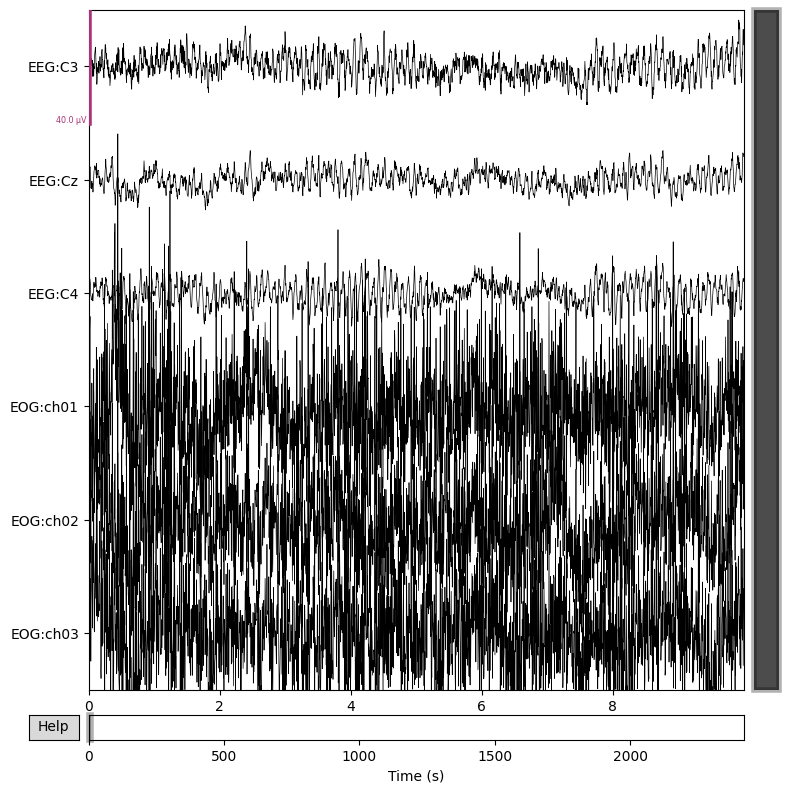

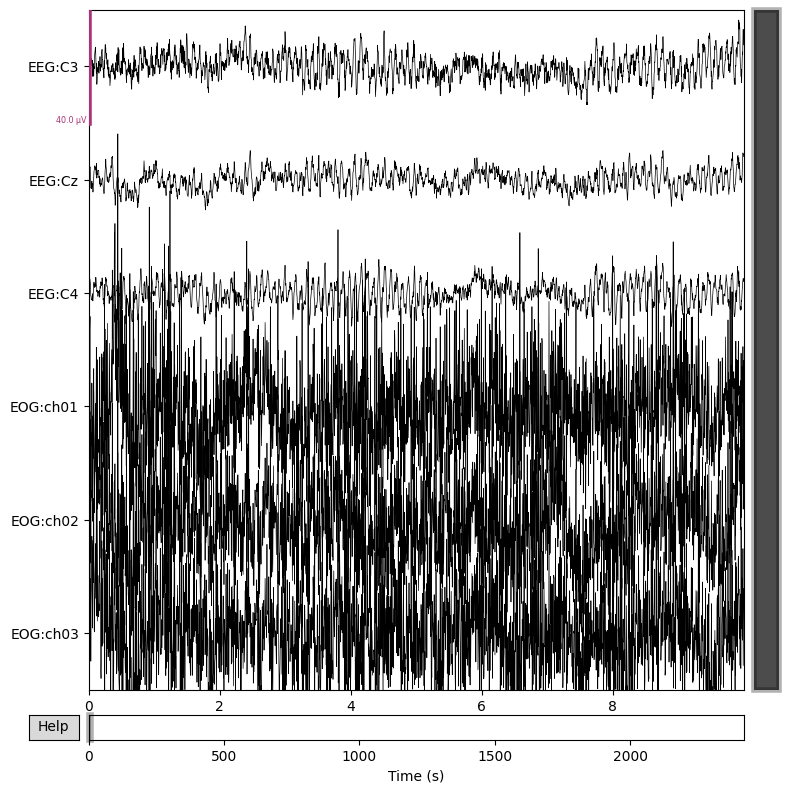

In [ ]:
raw.plot()

In [ ]:
raw = mne.io.read_raw_gdf("B0101T.gdf",
                          preload=True,
                          stim_channel=None)


Extracting GDF parameters from B0101T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG:C3, EEG:Cz, EEG:C4, EOG:ch01, EOG:ch02, EOG:ch03
Creating raw.info structure...
Reading 0 ... 604802  =      0.000 ...  2419.208 secs...


/tmp/ipython-input-312997215.py:1: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf("B0101T.gdf",


In [ ]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)


Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770')]
{np.str_('1023'): 1, np.str_('1077'): 2, np.str_('1078'): 3, np.str_('1079'): 4, np.str_('1081'): 5, np.str_('276'): 6, np.str_('277'): 7, np.str_('32766'): 8, np.str_('768'): 9, np.str_('769'): 10, np.str_('770'): 11}


In [ ]:
events, _ = mne.events_from_annotations(raw)

event_id = {
    'Left': 10,   # 769
    'Right': 11   # 770
}


Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770')]


In [ ]:
epochs = mne.Epochs(raw,
                    events,
                    event_id=event_id,
                    tmin=0,
                    tmax=4,
                    baseline=None,
                    preload=True)

print(epochs)


Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 1001 original time points ...
0 bad epochs dropped
<Epochs | 120 events (all good), 0 – 4 s (baseline off), ~5.5 MiB, data loaded,
 'Left': 60
 'Right': 60>


In [ ]:
X = epochs.get_data()
y = epochs.events[:, -1]

print(X.shape)
print("Unique labels:", np.unique(y))


(120, 6, 1001)
Unique labels: [10 11]


In [ ]:
epochs.pick_types(eeg=True)

X = epochs.get_data()

print(X.shape)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
(120, 6, 1001)


In [ ]:
print(epochs.info)
print(epochs.ch_names)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG:C3, EEG:Cz, EEG:C4, EOG:ch01, EOG:ch02, EOG:ch03
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2005-10-25 09:35:11 UTC
 nchan: 6
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: B01, sex: 0, last_name: X, birthday: 1984-12-01>
>
['EEG:C3', 'EEG:Cz', 'EEG:C4', 'EOG:ch01', 'EOG:ch02', 'EOG:ch03']


In [ ]:
epochs = epochs.copy().pick(['EEG:C3', 'EEG:Cz', 'EEG:C4'])

X = epochs.get_data()

print(X.shape)


(120, 3, 1001)


In [ ]:
y = epochs.events[:, -1]
y = (y == 11).astype(int)  # 0 = Left, 1 = Right


In [ ]:
import numpy as np
print("Unique labels:", np.unique(y))
print("Class counts:", np.bincount(y))


Unique labels: [0 1]
Class counts: [60 60]


In [ ]:
epochs.filter(8., 30., fir_design='firwin')
X = epochs.get_data()


Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



In [ ]:
epochs_filtered = epochs.copy().filter(8., 30., fir_design='firwin')

X = epochs_filtered.get_data()


Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



In [ ]:
X = epochs_filtered.get_data()
print(X.shape)


(120, 3, 1001)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

import numpy as np
print("Train class balance:", np.bincount(y_train))
print("Test class balance:", np.bincount(y_test))


Train shape: (84, 3, 1001)
Test shape: (36, 3, 1001)
Train class balance: [42 42]
Test class balance: [18 18]


In [ ]:
from mne.decoding import CSP

csp = CSP(n_components=2, reg=None, log=True, norm_trace=False)

X_train_csp = csp.fit_transform(X_train, y_train)
X_test_csp = csp.transform(X_test)

print("CSP Train shape:", X_train_csp.shape)
print("CSP Test shape:", X_test_csp.shape)


Computing rank from data with rank=None
    Using tolerance 6.3e-07 (2.2e-16 eps * 3 dim * 9.5e+08  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
CSP Train shape: (84, 2)
CSP Test shape: (36, 2)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_csp, y_train)

y_pred = lda.predict(X_test_csp)


In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("Accuracy:", acc)
print("Kappa:", kappa)


Accuracy: 0.8055555555555556
Kappa: 0.6111111111111112
